<a href="https://colab.research.google.com/github/febriyansyah-id/COLLAB/blob/main/notebooks/computer-vision/Vision-assignment-P05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LeNet-5 dan AlexNet: Perbandingan Arsitektur CNN

**Topik:** CNN dan arsitektur awal  
**Dataset:** MNIST dan CIFAR-10  

Notebook ini mendokumentasikan implementasi LeNet-5 pada MNIST dan AlexNet pada CIFAR-10. Eksperimen mencakup perbandingan arsitektur serta analisis pengaruh learning rate dan batch size terhadap proses pelatihan. Hasil evaluasi disajikan berdasarkan metrik yang dihasilkan langsung oleh program.


## BAB 1 — PENDAHULUAN

### 1.1 Latar Belakang

Klasifikasi citra digital adalah salah satu masalah paling klasik dalam computer vision. Tugasnya sederhana: diberi sebuah citra, sistem harus menentukan kelas apa yang direpresentasikan citra itu, misalnya angka nol, pesawat terbang, atau kucing.

Pendekatan yang paling awal adalah memipihkan citra menjadi satu vektor panjang, lalu menyambungkannya ke lapisan fully connected. Masalahnya segera terlihat pada jumlah parameter. Untuk citra RGB berukuran 224 x 224 dengan satu hidden layer berisi 1.000 neuron, bobot pada lapisan pertama saja sudah mencapai 224 x 224 x 3 x 1.000 = 150.528.000 parameter. Angka itu membengkak secara kuadratik terhadap ukuran citra, membuat proses pelatihan sangat lambat. Yang lebih parah, model semacam ini tidak memahami bahwa piksel yang berdekatan dalam citra saling berkaitan, sehingga model menghafal data training dan kemampuan generalisasinya menjadi buruk.

Convolutional neural network menjawab persoalan tersebut. Alih-alih menyambungkan setiap neuron ke seluruh piksel, CNN hanya menyambungkannya ke sebagian kecil piksel tetangga, yaitu bidang yang disebut *receptive field*, dan bobot yang dipakai di seluruh posisi piksel itu berbagi. Akibatnya jumlah parameter tidak lagi bergantung pada ukuran citra, dan jaringan secara alami belajar bahwa fitur yang sama dapat muncul di bagian mana saja.

### 1.2 Rumusan Masalah

Berdasarkan latar belakang tersebut, beberapa pertanyaan muncul yang ingin dijawab dalam eksperimen ini:

1. Apakah LeNet-5, yang dirancang lebih dari dua dekade lalu, masih mencapai akurasi tinggi pada MNIST dengan implementasi modern?
2. Apakah AlexNet dapat diadaptasi untuk CIFAR-10 yang resolusinya jauh lebih kecil daripada ImageNet asli?
3. Seberapa besar pengaruh learning rate terhadap stabilitas dan kecepatan konvergensi?
4. Seberapa besar pengaruh batch size terhadap kualitas solusi akhir dan waktu satu epoch?
5. Dari seluruh konfigurasi, mana yang terbaik, dan apakah masih terjadi overfitting?

### 1.3 Tujuan

Tujuan eksperimen ini adalah mengimplementasikan LeNet-5 untuk MNIST dan AlexNet untuk CIFAR-10, mengukur setiap konfigurasi secara konsisten, serta membandingkan pengaruh hyperparameter terhadap kemampuan klasifikasi citra.

### 1.4 Manfaat

Dari sisi akademik, eksperimen ini menunjukkan bahwa kemajuan computer vision tidak hanya berasal dari arsitektur yang lebih dalam, melainkan juga dari pilihan pelatihan yang cermat. Dari sisi praktis, prosedur evaluasi yang dipakai di sini, yaitu loss, akurasi, waktu, dan generalization gap, dapat langsung diterapkan pada dataset yang lebih besar maupun pada arsitektur yang lebih mutakhir.

## BAB 2 — TINJAUAN PUSTAKA

Bab ini menguraikan konsep yang dipakai pada implementasi. Pembahasan disusun dari yang paling dasar, yaitu operasi matematis konvolusi, lalu berlanjut ke pooling, receptive field, regularisasi, dan aktivasi. Bagian berikutnya membahas dua arsitektur utama secara rinci, ditutup dengan optimizer, metrik evaluasi, serta kaitannya dengan arsitektur modern yang akan dipelajari pada pembahasan pada bagian selanjutnya.

### 2.1 Operasi Konvolusi 2D

Konvolusi adalah operasi inti CNN. Secara matematis, konvolusi 2D dari sebuah input `I` dengan kernel `K` adalah:

`(I * K)[i, j] = sum_m sum_n K[m, n] * I[i + m, j + n]`

Dalam implementasi nyata, proses ini dioptimalkan menjadi *cross-correlation*, yaitu kernel digeser tanpa dibalik. Hasilnya tetap sesuai untuk keperluan belajar, tetapi jauh lebih murah secara komputasi.

Satu kernel hanya menghasilkan satu feature map, yaitu kumpulan nilai respons kernel terhadap pola-pola lokal di seluruh citra. Kernel dengan bobot berbeda menangkap pola yang berbeda pula. Filter pertama umumnya bereaksi terhadap garis dan sudut, sedangkan filter yang lebih dalam bereaksi terhadap bentuk yang lebih abstrak.

### 2.2 Padding, Stride, dan Ukuran Output

Tiga parameter menentukan bentuk feature map. **Padding** menambahkan nol di tepi input agar ukuran tidak menyusut berlebihan dan agar piksel di tepi citra tetap dapat merespons pola di sebelahnya. **Stride** menentukan seberapa jauh kernel digeser; stride lebih besar berarti pengurangan resolusi lebih cepat sekaligus komputasi lebih murah, dengan konsekuensi informasi spasial ikut berkurang.

Ukuran output feature map dirumuskan:

`W_out = floor((W_in - K + 2P) / S) + 1`

Beberapa perhitungan pada LeNet-5 dapat diperiksa langsung:

| Lapisan | W_in | K | P | S | W_out |
|---|---:|---:|---:|---:|---:|
| Conv1 | 32 | 5 | 0 | 1 | `floor((32 - 5 + 0)/1) + 1 = 28` |
| AvgPool1 | 28 | 2 | 0 | 2 | `floor((28 - 2 + 0)/2) + 1 = 14` |
| Conv2 | 14 | 5 | 0 | 1 | `floor((14 - 5 + 0)/1) + 1 = 10` |
| AvgPool2 | 10 | 2 | 0 | 2 | `floor((10 - 2 + 0)/2) + 1 = 5` |
| Conv3 | 5 | 5 | 0 | 1 | `floor((5 - 5 + 0)/1) + 1 = 1` |

Conv3 menghasilkan feature map berukuran 1 x 1, sehingga seluruh citra sudah terangkum menjadi satu vektor deskriptor. Lapisan berikutnya otomatis bekerja seperti fully connected layer. Inilah yang membuat LeNet-5 bisa selingkas ini.

### 2.3 Konvolusi Multi-Channel dan Multi-Filter

Pada citra RGB, input bukan dua dimensi melainkan tiga, yaitu `H x W x 3`. Karena itu kernel harus tiga dimensi juga, yaitu `K x K x C_in`. Konvolusi dihitung dengan menjumlahkan kontribusi dari seluruh channel sekaligus.

Banyak filter menghasilkan banyak feature map. Jumlah parameter pada satu lapisan konvolusi hanya bergantung pada ukuran kernel dan jumlah channel, bukan pada ukuran citra:

`params = (K x K x C_in + 1) x C_out`

Tambahan satu adalah bias. Dua hal terjadi sekaligus. Pertama, seluruh feature map digabung menjadi sebuah tensor dengan `C_out` channel. Kedua, channel baru itu bisa diperlakukan sebagai citra grayscale baru pada lapisan berikutnya, sehingga jaringan dapat terus menurunkan resolusi. Inilah yang membuat LeNet-5 cukup dengan 61.706 parameter untuk MNIST, sementara AlexNet yang memakai `C_out` besar membutuhkan jutaan parameter.

### 2.4 Fungsi Aktivasi

Tanpa fungsi aktivasi, menumpuk lapisan konvolusi sama dengan hanya menyusun satu transformasi linear. Jaringan tidak akan punya kapasitas untuk memodelkan relasi non-linear, dan seberapa pun dalam jaringan, kinerjanya tetap sama dengan model linear.

Fungsi aktivasi yang dipakai pada kedua arsitektur ini berbeda, dan perbedaannya memiliki makna historis:

- **Tanh pada LeNet-5.** Dipakai pada tahun 1998, ketika pilihan fungsi aktivasi masih terbatas. Tanh memiliki gradien yang kecil untuk nilai ekstrim sehingga mudah mengalami *vanishing gradient* pada jaringan dalam. Nilai tanh(x) juga selalu berada pada rentang minus satu sampai satu, sehingga komputasinya lebih lambat dibanding ReLU.
- **ReLU pada AlexNet.** `f(x) = max(0, x)`. ReLU punya tiga keunggulan. Harganya lebih murah dihitung, gradien tidak macet selama unit masih aktif sehingga jaringan dapat dilatih lebih dalam, dan ReLU menghasilkan *sparsity* karena sebagian besar unit mati, yang tanpa sengaja menjadi regularisasi ringan. He et al. (2015) menunjukkan bahwa inisialisasi yang terlalu konservatif justru membuat sebagian besar unit mati permanen, sehingga diperlukan penyesuaian inisialisasi khusus.

### 2.5 Pooling

Pooling mengecilkan dimensi spasial tanpa parameter yang dipelajari. **Max pooling** mengambil nilai terbesar di dalam region, sedangkan **average pooling** mengambil rata-ratanya. Keduanya sama-sama menurunkan jumlah komputasi, tetapi max pooling lebih umum pada arsitektur modern karena lebih tahan terhadap pergeseran.

Secara konseptual, pooling menambahkan sifat *translation invariance* pada model: objek yang bergeser beberapa piksel tetap menghasilkan representasi yang serupa. AlexNet memakai max pooling, sedangkan LeNet-5 memilih average pooling. Pilihan LeNet-5 kini dianggap kurang ideal, karena average pooling cenderung mengaburkan informasi yang bersifat lokal yang justru penting untuk pengenalan digit.

### 2.6 Receptive Field

Receptive field adalah area input yang memengaruhi nilai satu neuron tertentu. Ukurannya berkembang secara progresif mengikuti rumus `r_j = r_(j-1) + (k_j - 1) * jump_(j-1)`. Pada LeNet-5, receptive field dimulai dari 1 piksel, menjadi 5 setelah Conv1, 6 setelah AvgPool1, 14 setelah Conv2, 16 setelah AvgPool2, dan akhirnya 32 setelah Conv3.

Artinya satu neuron pada lapisan ketiga merespons seluruh citra 32 x 32. Walaupun setiap neuron hanya melihat sebagian kecil citra, komposisi lapisan tersebut memungkinkan jaringan membangun representasi yang semakin kompleks hingga membentuk objek utuh.

### 2.7 Normalisasi Input

Sebelum masuk ke jaringan, nilai piksel perlu dinormalisasi. Untuk MNIST, rerata adalah 0.1307 dan standar deviasi 0.3081. Untuk CIFAR-10, rerata per channel adalah (0.4914, 0.4822, 0.4465) dan standar deviasinya (0.2470, 0.2435, 0.2616). Normalisasi membuat jarak pada optimasi konsisten antar channel, sehingga learning rate yang sama dapat dipakai di seluruh lapisan.

### 2.8 Regularisasi

Model yang jauh lebih besar daripada jumlah data training akan menghafal data tersebut dan gagal pada data baru. Kedua arsitektur ini belum memakai batch normalization (Ioffe dan Szegedy, 2015), sehingga regularisasi datang dari beberapa arah:

- **Weight decay**, yaitu penalti L2 pada bobot, menekan bobot agar tidak tumbuh berlebihan.
- **Dropout** (Srivastava et al., 2014), yaitu mengaktifkan sebagian unit secara acak saat pelatihan. AlexNet memakai dropout 0.5 pada classifier, sebagian besar karena ukuran fully connected layer-nya yang sangat besar.
- **Data augmentation**, yaitu membuat variasi artificial dari data training. Pada eksperimen ini AlexNet memakai `RandomHorizontalFlip` dan `RandomCrop(32, padding=4)`, dua teknik augmentasi yang disebut dalam paper aslinya.

### 2.9 LeNet-5

LeNet-5 adalah arsitektur yang merintis pengenalan karakter tulisan tangan. Struktur dan jumlah parameternya adalah sebagai berikut.

| Bagian | Lapisan | Bentuk Output | Parameter |
|---|---|---|---:|
| features | Conv2d 1 to 6, k5, Tanh | 6 x 28 x 28 | 156 |
| | AvgPool2d 2 | 6 x 14 x 14 | 0 |
| | Conv2d 6 to 16, k5, Tanh | 16 x 10 x 10 | 2.416 |
| | AvgPool2d 2 | 16 x 5 x 5 | 0 |
| | Conv2d 16 to 120, k5, Tanh | 120 x 1 x 1 | 48.120 |
| classifier | Linear 120 to 84, Tanh | 84 | 10.164 |
| | Linear 84 to 10 | 10 | 850 |
| | **Total** | | **61.706** |

Arsitektur ini hanya membutuhkan 61.706 parameter, jumlah yang bahkan tidak sebanding dengan satu hidden layer MLP berukuran sedang. Untuk data MNIST yang hanya berukuran 28 x 28 dan grayscale, kapasitas tersebut sudah lebih dari cukup.

### 2.10 AlexNet

AlexNet adalah paper yang memulai revolusi deep learning. Pada kompetisi ImageNet 2012, AlexNet menurunkan top-5 error dari 34,2 persen pada pesaing terbaik saat itu menjadi 15,3 persen. Lompatan sebesar itu memicu peralihan mendasar dari metode tradisional ke deep learning.

| Bagian | Lapisan | Keterangan |
|---|---|---|
| features | Conv 3 to 64, k3, p1, ReLU, MaxPool 2 | resolusi 32 to 16 |
| | Conv 64 to 192, k3, p1, ReLU, MaxPool 2 | 16 to 8 |
| | Conv 192 to 384, k3, p1, ReLU | 8 to 8 |
| | Conv 384 to 256, k3, p1, ReLU | 8 to 8 |
| | Conv 256 to 256, k3, p1, ReLU, MaxPool 2 | 8 to 4 |
| classifier | Flatten menjadi 256 x 4 x 4 = 4.096 | |
| | Dropout 0.5, Linear 4.096 to 1.024, ReLU | |
| | Dropout 0.5, Linear 1.024 to 10 | |

Kontribusi utama AlexNet bukan hanya arsitekturnya, melainkan gabungan beberapa keputusan pelatihan: penggunaan ReLU agar gradien tidak hilang, dropout untuk menahan overfitting, augmentasi data melalui crop dan horizontal flip untuk memperluas data training, serta pelatihan di atas GPU menggunakan dua kartu secara paralel.

**Adaptasi untuk CIFAR-10.** AlexNet asli menerima citra 224 x 224, sedangkan CIFAR-10 hanya 32 x 32. Menyalin arsitektur apa adanya akan membuat feature map menyusut terlalu cepat sebelum mencapai classifier. Adaptasi pada notebook ini mempertahankan kelima lapisan konvolusi, ReLU, max pooling, dan dropout, tetapi memakai kernel 3 dengan padding 1, serta mengganti ukuran fully connected dari 256 x 6 x 6 = 9.216 pada arsitektur asli menjadi 256 x 4 x 4 = 4.096 pada versi ini. Inilah alasan turunan yang sering disebut AlexNet untuk CIFAR bukan replika AlexNet asli, melainkan turunan yang mengikuti gagasan yang sama pada skala input yang berbeda.

### 2.11 Optimizer dan Peran Learning Rate

Algoritma yang dipakai pada notebook ini adalah Adam (Kingma dan Ba, 2015), yang menggabungkan momentum dengan estimasi adaptif gradien sehingga setiap parameter dapat memakai langkah berbeda. Adam sering dipilih karena lebih cepat konvergen dan tidak membutuhkan penyetelan learning rate seketat SGD, tetapi learning rate tetap merupakan hyperparameter yang paling berpengaruh:

- **Terlalu besar**, misalnya 1e-2 dengan batch kecil, membuat optimizer melompati lembah loss minimum. Training loss dapat naik-turun tidak stabil, bahkan berosilasi, dan akurasi akhir menurun.
- **Terlalu kecil**, misalnya 1e-4, membuat langkah update sangat halus sehingga training berjalan, tetapi membutuhkan jauh lebih banyak epoch untuk mencapai loss yang sama.
- **Sesuai**, sekitar 1e-3, memberi konvergensi cepat tanpa instabilitas berarti.

### 2.12 Peran Batch Size

Batch size adalah jumlah contoh yang diproses bersama-sama dalam satu langkah update. Batch size memengaruhi tiga hal sekaligus. Pertama, **noise gradien**: batch kecil menghasilkan estimasi yang lebih bising, yang justru dapat membantu keluar dari *sharp minima*, tetapi terlalu kecil membuat pelatihan tidak stabil. Kedua, **kebutuhan memori**, karena seluruh batch harus ditahan sekaligus di GPU. Ketiga, **waktu per epoch**: batch besar mengurangi overhead Python dan membuat pemakaian GPU lebih efisien, tetapi memproses lebih banyak data sekaligus.

Selain itu, batch size menentukan learning rate yang sesuai menurut aturan penskalaan linear yang lazim (Smith et al., 2015). Karena itu kedua hyperparameter ini sebaiknya diubah bersama, bukan sendirian.

### 2.13 Metrik Evaluasi

Empat besaran dipakai pada laporan ini. **Loss** dihitung dengan cross-entropy, yaitu mengukur seberapa jauh distribusi prediksi dari label sebenarnya; cross-entropy yang rendah berarti model yakin dan benar. **Accuracy** adalah proporsi prediksi yang benar; metrik ini mudah dibaca, tetapi bisa menipu ketika kelas tidak seimbang. **Waktu per epoch** secara tidak langsung mengukur efisiensi konfigurasi. **Generalization gap** adalah selisih akurasi training dan akurasi test; gap yang besar menandakan overfitting, yaitu model menghafal data training namun gagal menggeneralisasi pada data baru.

### 2.14 Arah Pengembangan Menuju Arsitektur Modern

LeNet-5 dan AlexNet membuktikan bahwa convolutional network dapat bekerja pada skala yang jauh lebih besar. Pertemuan berikutnya membahas arsitektur yang menjawab keterbatasan keduanya. **ResNet** (He et al., 2016) menambahkan residual connection `y = F(x) + x` agar gradien tetap mengalir pada jaringan yang sangat dalam. **MobileNet** (Howard et al., 2017) mengganti konvolusi biasa dengan depthwise separable convolution agar model lebih ringan. **EfficientNet** (Tan dan Le, 2019) menyeimbangkan kedalaman, lebar, dan resolusi input. **ConvNeXt** (Liu et al., 2022) menunjukkan bahwa CNN murni masih dapat bersaing dengan transformer. **Transfer learning** memanfaatkan bobot pretrained agar dataset kecil tetap dapat dilatih dengan baik.

Eksperimen pada laporan ini menjadi fondasi untuk berpindah ke topik tersebut, sebab cara mengukur konvergensi dan generalisasi tidak berubah. Yang berubah hanya arsitekturnya.

## BAB 3 — METODOLOGI PENELITIAN

### 3.1 Alur Percobaan

Percobaan disusun dalam dua tahap. Tahap pertama melatih masing-masing arsitektur sebagai baseline dengan hyperparameter yang sama, sehingga perbedaan performa hanya mencerminkan perbedaan arsitektur. Tahap kedua memvariasikan learning rate dan batch size pada satu arsitektur untuk mengisolasi pengaruh hyperparameter. Tahap kedua sengaja dijalankan pada LeNet-5 dengan MNIST karena dataset ini jauh lebih ringan, sehingga tiga konfigurasi dapat dibandingkan dengan biaya komputasi yang masuk akal.

Agar hasil dapat dibandingkan, `torch.manual_seed(42)` dipasang ulang pada setiap konfigurasi, `cudnn.deterministic` diaktifkan, dan `cudnn.benchmark` dimatikan. Tanpa langkah ini, perbedaan hasil antar konfigurasi bisa jadi hanya mencerminkan faktor acak, bukan efek hyperparameter yang benar-benar diteliti.

### 3.2 Lingkungan Eksperimen dan Spesifikasi Google Colab

Lingkungan ini dipilih karena menyediakan akselerator GPU tanpa konfigurasi perangkat keras lokal, dan karena versi PyTorch di dalamnya telah terkonfigurasi, sehingga hasil dapat direproduksi oleh pembaca lain.

#### Mengaktifkan akselerator GPU

Akselerator diaktifkan melalui menu **Runtime → Change runtime type**, kemudian memilih **Hardware accelerator: GPU**. Setelah itu runtime perlu dijalankan ulang. Pemeriksaan apakah GPU benar-benar aktif dilakukan pada subbab 3.3, bukan diasumsikan.

#### Persyaratan perangkat keras

Beban kerja notebook ini tergolong ringan. Kedua model berukuran kecil, yaitu LeNet-5 dengan 61.706 parameter dan AlexNet yang diadaptasi dengan sekitar 6,5 juta parameter, serta seluruh citra berukuran 32 x 32. Kebutuhan memori video karena itu jauh di bawah kapasitas akselerator mana pun yang disediakan Colab.

| Profil | Akselerator | Memori video | Penilaian |
|---|---|---|---|
| Minimum | T4 | 16 GB | Lebih dari cukup untuk seluruh eksperimen |
| Direkomendasikan | L4 | 24 GB | Nyaman, dengan ruang untuk epoch lebih banyak |
| Berlebihan | A100 | 40 GB | Tidak diperlukan pada beban kerja ini |

Kebutuhan memori perkiraan berada di bawah 4 GB, dengan puncak pemakaian pada lapisan fully connected AlexNet saat batch 128 dan resolusi 32 x 32. Karena itu T4, yaitu akselerator yang paling umum tersedia pada Colab, sudah memadai. Menjalankan notebook pada CPU tetap memungkinkan, tetapi durasi training meningkat secara signifikan sehingga pengujian berulang menjadi tidak praktis.

Dari sisi memori sistem, kebutuhan Ram sekitar 8 GB, dengan tambahan ruang disk sekitar 200 MB untuk mengunduh MNIST dan CIFAR-10.

### 3.3 Verifikasi GPU dan Konfigurasi Eksperimen

Pemeriksaan perangkat keras dijalankan lebih dahulu agar penggunaan GPU tercatat sebagai bukti dalam keluaran notebook, bukan sekadar asumsi. Nilai `EPOCHS` dapat dinaikkan untuk training yang lebih panjang, sedangkan `SUBSET_TRAIN` menyediakan jalan pintas untuk menguji notebook dengan cepat tanpa memproses seluruh dataset.

In [11]:
%pip install -q torch torchvision matplotlib pandas tqdm

In [12]:
import subprocess
import sys
import time

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import pandas as pd
from tqdm.auto import tqdm

# Reproducibility
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Konfigurasi eksperimen
EPOCHS = 5
SUBSET_TRAIN = None  # Ubah ke mis. 10000 untuk uji cepat; None = penuh
NUM_WORKERS = 0

In [13]:
# ============================================================
# VERIFIKASI LINGKUNGAN EKSEKUSI
# ============================================================
print('=== RINGKASAN LINGKUNGAN EKSEKUSI ===')
print('Python       :', sys.version.split()[0])
print('PyTorch      :', torch.__version__)
print('CUDA builds  :', torch.version.cuda)
print('CUDA tersedia:', torch.cuda.is_available())

if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f'GPU          : {props.name}')
    print(f'Memori video : {props.total_memory / 1024**3:.1f} GB')
    print(f'Compute cap. : {props.major}.{props.minor}')
    print(f'Jumlah GPU   : {torch.cuda.device_count()}')
    try:
        smi = subprocess.run(
            ['nvidia-smi', '--query-gpu=name,memory.total,driver_version',
             '--format=csv,noheader'],
            capture_output=True, text=True, timeout=10)
        if smi.returncode == 0 and smi.stdout.strip():
            print('nvidia-smi   :', smi.stdout.strip())
    except (FileNotFoundError, subprocess.SubprocessError):
        pass
else:
    print('GPU          : TIDAK TERSEDIA')
    print('Training akan berjalan pada CPU dan jauh lebih lambat.')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device aktif :', device)

=== RINGKASAN LINGKUNGAN EKSEKUSI ===
Python       : 3.13.15
PyTorch      : 2.11.0+cu128
CUDA builds  : 12.8
CUDA tersedia: True
GPU          : Tesla T4
Memori video : 14.6 GB
Compute cap. : 7.5
Jumlah GPU   : 1
nvidia-smi   : Tesla T4, 15360 MiB, 580.82.07
Device aktif : cuda


### 3.4 Arsitektur Model

Kedua model dituliskan langsung mengikuti definisi pada tinjauan pustaka. LeNet-5 mengikuti struktur asli, sedangkan AlexNet mengikuti hasil adaptasi untuk resolusi 32 x 32. Perbedaan mencolok pada keduanya dapat diamati langsung dari kode. LeNet-5 memakai Tanh dan average pooling dengan kernel 5 tanpa padding, sementara AlexNet memakai ReLU, max pooling, dropout, dan kernel 3 dengan padding 1 yang menjaga ukuran feature map tetap utuh.

In [18]:
class LeNet5(nn.Module):
    """LeNet-5 untuk MNIST dengan input 1x32x32."""

    def __init__(self, classes=10):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5),
            nn.Tanh(),
            nn.AvgPool2d(2),

            nn.Conv2d(6, 16, kernel_size=5),
            nn.Tanh(),
            nn.AvgPool2d(2),

            nn.Conv2d(16, 120, kernel_size=5),
            nn.Tanh()
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(120, 84),
            nn.Tanh(),
            nn.Linear(84, classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


class AlexNetCIFAR(nn.Module):
    """AlexNet yang diadaptasi untuk input CIFAR-10 3x32x32."""

    def __init__(self, classes=10):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 192, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256 * 4 * 4, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(1024, classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

Penelusuran berikut memverifikasi dua hal sekaligus, dan keduanya dijalankan sebagai pemeriksaan otomatis. Pertama, jumlah parameter dihitung ulang per lapisan memakai rumus `(K x K x C_in + 1) x C_out`, lalu dibandingkan dengan parameter yang benar-benar dipegang PyTorch; jika angkanya cocok, implementasi rumus tersebut benar. Kedua, bentuk tensor dilacak melewati setiap lapisan untuk memastikan `W_out = floor((W_in - K + 2P) / S) + 1` benar-benar berlaku dan feature map tidak habis sebelum mencapai classifier. Penghitungan manual pada tabel di Bab 2 akan terbukti benar di sini.

In [20]:
def layer_table(model):
    """Ringkasan lapisan berbobot dan jumlah parameternya."""
    rows = []
    manual_total = 0

    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            k = module.kernel_size[0]
            params = (
                (k * k * module.in_channels + 1)
                * module.out_channels
            )
            formula = (
                f"({k}*{k}*{module.in_channels} + 1)"
                f"*{module.out_channels}"
            )
            desc = (
                f"Conv2d {module.in_channels}->{module.out_channels}, "
                f"k{k}, p{module.padding[0]}, s{module.stride[0]}"
            )

        elif isinstance(module, nn.Linear):
            params = (
                (module.in_features + 1)
                * module.out_features
            )
            formula = (
                f"({module.in_features} + 1)"
                f"*{module.out_features}"
            )
            desc = (
                f"Linear {module.in_features}"
                f"->{module.out_features}"
            )

        else:
            continue

        manual_total += params
        rows.append((name, desc, formula, params))

    actual_total = sum(
        parameter.numel()
        for parameter in model.parameters()
    )

    return rows, manual_total, actual_total


def shape_trace(model, shape):
    """Melacak bentuk tensor pada setiap feature extractor."""
    model.eval()

    x = torch.zeros(shape)
    sizes = [tuple(x.shape)]

    with torch.no_grad():
        for layer in model.features:
            x = layer(x)
            sizes.append(tuple(x.shape))

    return sizes


models_to_check = [
    ("LeNet-5", LeNet5(), (1, 1, 32, 32)),
    ("AlexNet-CIFAR", AlexNetCIFAR(), (1, 3, 32, 32)),
]


for name, model, shape in models_to_check:
    rows, manual_total, actual_total = layer_table(model)

    print(f"\n=== {name} ===")
    print(
        f'{"lapisan":<14}'
        f'{"deskripsi":<32}'
        f'{"rumus":<30}'
        f'{"parameter":>12}'
    )

    for layer_name, desc, formula, params in rows:
        print(
            f"{layer_name:<14}"
            f"{desc:<32}"
            f"{formula:<30}"
            f"{params:>12,}"
        )

    print(
        f'{"":<14}'
        f'{"":<32}'
        f'{"total (rumus)":<30}'
        f'{manual_total:>12,}'
    )

    print(
        f'{"":<14}'
        f'{"":<32}'
        f'{"total (PyTorch)":<30}'
        f'{actual_total:>12,}'
    )

    assert manual_total == actual_total, (
        f"{name}: hitungan {manual_total} "
        f"!= PyTorch {actual_total}"
    )

    print("COCOK: hitungan manual sama dengan parameter PyTorch")

    tensor_shapes = shape_trace(model, shape)
    print(
        "Bentuk tensor:",
        " -> ".join(str(size) for size in tensor_shapes)
    )


=== LeNet-5 ===
lapisan       deskripsi                       rumus                            parameter
features.0    Conv2d 1->6, k5, p0, s1         (5*5*1 + 1)*6                          156
features.3    Conv2d 6->16, k5, p0, s1        (5*5*6 + 1)*16                       2,416
features.6    Conv2d 16->120, k5, p0, s1      (5*5*16 + 1)*120                    48,120
classifier.1  Linear 120->84                  (120 + 1)*84                        10,164
classifier.3  Linear 84->10                   (84 + 1)*10                            850
                                              total (rumus)                       61,706
                                              total (PyTorch)                     61,706
COCOK: hitungan manual sama dengan parameter PyTorch
Bentuk tensor: (1, 1, 32, 32) -> (1, 6, 28, 28) -> (1, 6, 28, 28) -> (1, 6, 14, 14) -> (1, 16, 10, 10) -> (1, 16, 10, 10) -> (1, 16, 5, 5) -> (1, 120, 1, 1) -> (1, 120, 1, 1)

=== AlexNet-CIFAR ===
lapisan       deskri

### 3.5 Dataset dan Transformasi

MNIST berisi 60.000 citra training grayscale berukuran 28 x 28 dengan label 0 sampai 9. Karena arsitektur LeNet-5 mengharuskan input 32 x 32, citra di-resize lebih dulu sebelum dinormalisasi dengan rerata 0.1307 dan standar deviasi 0.3081.

CIFAR-10 berisi 50.000 citra training dan 10.000 citra test RGB 32 x 32 dalam sepuluh kelas. Pada data training ditambahkan augmentasi `RandomHorizontalFlip` dan `RandomCrop(32, padding=4)` sesuai rekomendasi paper aslinya, sedangkan data test memakai transformasi polos tanpa augmentasi. Tanpa pemisahan ini, metrik evaluasi akan tercemar oleh variasi acak dan sulit direproduksi. Padding sebesar empat piksel pada `RandomCrop` juga menjaga agar isi citra tidak terpotong habis ketika dipotong kembali ke 32 x 32.

In [21]:
# ============================================================
# DATA LOADING
# ============================================================

# MNIST: resize ke 32x32 agar cocok LeNet-5
mnist_tf = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# CIFAR-10 train: augmentasi sesuai kontribusi AlexNet (flip + random crop padding 4)
cifar_train_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

# CIFAR-10 test: tanpa augmentasi agar evaluasi deterministik
cifar_test_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

# Download datasets
mnist_train = datasets.MNIST('data', train=True, download=True, transform=mnist_tf)
mnist_test = datasets.MNIST('data', train=False, download=True, transform=mnist_tf)
cifar_train = datasets.CIFAR10('data', train=True, download=True, transform=cifar_train_tf)
cifar_test = datasets.CIFAR10('data', train=False, download=True, transform=cifar_test_tf)

print(f'MNIST train: {len(mnist_train)}, test: {len(mnist_test)}')
print(f'CIFAR-10 train: {len(cifar_train)}, test: {len(cifar_test)}')

100%|██████████| 9.91M/9.91M [00:00<00:00, 62.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.67MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.7MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.95MB/s]
100%|██████████| 170M/170M [23:04<00:00, 123kB/s]


MNIST train: 60000, test: 10000
CIFAR-10 train: 50000, test: 10000


### 3.6 Loop Training dan Evaluasi

Fungsi `train_one_epoch` menghitung loss dan akurasi rata-rata per epoch dengan pembagi jumlah data, bukan jumlah batch, sehingga hasilnya tidak terpengaruh ukuran batch terakhir. Fungsi `evaluate` diberi dekorator `@torch.no_grad()` sehingga gradien tidak dibangun saat evaluasi; ini menghemat memori dan mempercepat proses secara signifikan. Keduanya ditulis dengan struktur yang sama supaya perbandingan antar konfigurasi benar-benar sebanding.

`run_experiment` membungkus keduanya dan mengembalikan riwayat per epoch. Karena seluruh eksperimen, baik baseline maupun sweep, memakai fungsi yang sama, setiap perbedaan angka pada tabel hanya berasal dari learning rate dan batch size, bukan dari perbedaan cara evaluasi.

In [22]:
def make_loaders(train_ds, test_ds, batch_size):
    if SUBSET_TRAIN is not None and len(train_ds) > SUBSET_TRAIN:
        train_ds = Subset(train_ds, range(SUBSET_TRAIN))
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=NUM_WORKERS)
    test_loader = DataLoader(test_ds, batch_size=max(batch_size, 256),
                             shuffle=False, num_workers=NUM_WORKERS)
    return train_loader, test_loader


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = correct = total = 0
    pbar = tqdm(loader, leave=False, desc='train')
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * labels.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += labels.size(0)
        pbar.set_postfix(loss=f'{total_loss / total:.4f}', acc=f'{correct / total:.4f}')
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = correct = total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss = criterion(logits, labels)
        total_loss += loss.item() * labels.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total


def run_experiment(model, train_ds, test_ds, lr, batch_size, epochs, criterion=None):
    """Latih satu konfigurasi dan kembalikan riwayat per epoch."""
    criterion = criterion or nn.CrossEntropyLoss()
    train_loader, test_loader = make_loaders(train_ds, test_ds, batch_size)
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = []
    for epoch in range(1, epochs + 1):
        t0 = time.perf_counter()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        te_loss, te_acc = evaluate(model, test_loader, criterion)
        duration = time.perf_counter() - t0
        history.append(dict(epoch=epoch, train_loss=tr_loss, train_acc=tr_acc,
                            test_loss=te_loss, test_acc=te_acc, seconds=duration))
        print(f'Epoch {epoch}/{epochs} | lr={lr:g} bs={batch_size} | '
              f'train loss {tr_loss:.4f} acc {tr_acc:.4f} | '
              f'test loss {te_loss:.4f} acc {te_acc:.4f} | {duration:.1f}s')
    return model, history, optimizer, criterion

### 3.7 Pelatihan LeNet-5 pada MNIST

LeNet-5 dilatih dengan Adam, learning rate 1e-3, batch size 128, selama lima epoch. Batch size 128 dipilih karena cukup besar untuk menghasilkan langkah gradien yang stabil, tetapi masih muat sepenuhnya pada memori GPU. Bobot model disimpan dalam berkas `.pt` beserta metadata hyperparameter, sehingga hasil pelatihan dapat dimuat ulang tanpa mengulang training.

In [23]:
criterion = nn.CrossEntropyLoss()
lenet_model, lenet_history, lenet_optimizer, criterion = run_experiment(
    LeNet5(), mnist_train, mnist_test, lr=1e-3, batch_size=128, epochs=EPOCHS,
    criterion=criterion)
torch.save({'model': lenet_model.state_dict(), 'lr': 1e-3, 'batch_size': 128},
           'lenet5_mnist.pt')
print('Checkpoint: lenet5_mnist.pt')

train:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 1/5 | lr=0.001 bs=128 | train loss 0.3290 acc 0.9115 | test loss 0.1127 acc 0.9672 | 24.4s


train:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 2/5 | lr=0.001 bs=128 | train loss 0.0909 acc 0.9729 | test loss 0.0697 acc 0.9779 | 22.8s


train:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 3/5 | lr=0.001 bs=128 | train loss 0.0588 acc 0.9823 | test loss 0.0549 acc 0.9818 | 22.2s


train:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 4/5 | lr=0.001 bs=128 | train loss 0.0447 acc 0.9862 | test loss 0.0500 acc 0.9844 | 22.5s


train:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 5/5 | lr=0.001 bs=128 | train loss 0.0352 acc 0.9892 | test loss 0.0442 acc 0.9864 | 22.6s
Checkpoint: lenet5_mnist.pt


### 3.8 Pelatihan AlexNet pada CIFAR-10

AlexNet dilatih dengan pengaturan baseline yang sama persis dengan LeNet-5, agar perbedaan hasil akhir mencerminkan arsitektur dan dataset, bukan hyperparameter. Karena AlexNet memiliki ribuan kali lebih banyak parameter dan dropout aktif selama training, learning rate yang sama masih berada pada rentang yang wajar untuk model sebesar ini.

In [24]:
alexnet_model, alexnet_history, alexnet_optimizer, criterion = run_experiment(
    AlexNetCIFAR(), cifar_train, cifar_test, lr=1e-3, batch_size=128, epochs=EPOCHS,
    criterion=criterion)
torch.save({'model': alexnet_model.state_dict(), 'lr': 1e-3, 'batch_size': 128},
           'alexnet_cifar10.pt')
print('Checkpoint: alexnet_cifar10.pt')

train:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 1/5 | lr=0.001 bs=128 | train loss 1.7015 acc 0.3620 | test loss 1.3317 acc 0.5038 | 38.0s


train:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 2/5 | lr=0.001 bs=128 | train loss 1.2876 acc 0.5321 | test loss 1.1014 acc 0.5978 | 37.5s


train:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 3/5 | lr=0.001 bs=128 | train loss 1.0892 acc 0.6126 | test loss 0.9601 acc 0.6584 | 36.9s


train:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 4/5 | lr=0.001 bs=128 | train loss 0.9515 acc 0.6665 | test loss 0.8134 acc 0.7125 | 36.5s


train:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 5/5 | lr=0.001 bs=128 | train loss 0.8513 acc 0.7042 | test loss 0.8693 acc 0.7053 | 36.5s
Checkpoint: alexnet_cifar10.pt


### 3.9 Eksperimen Hyperparameter

Tiga konfigurasi dijalankan pada LeNet-5 dengan MNIST. Konfigurasi A memakai learning rate 1e-2 dengan batch 64, konfigurasi B memakai 1e-3 dengan batch 128, dan konfigurasi C memakai 1e-4 dengan batch 256.

Pasangan ini disengaja. Learning rate diperbesar justru ketika batch diperkecil, dan dikecilkan ketika batch diperbesar, mengikuti hubungan linear antara keduanya (Smith et al., 2015), sehingga setiap konfigurasi tetap berada pada wilayah yang masuk akal. Seandainya learning rate besar dipasangkan dengan batch besar, konfigurasi itu akan gagal bukan karena satu variabel, melainkan karena kombinasi yang memang tidak proporsional.

Seluruh epoch dijalankan penuh pada ketiga konfigurasi, tanpa penghentian dini, agar pola konvergensinya terlihat pada grafik dan bukan hanya angka akhir.

In [25]:
SWEEP = [
    ('A', 1e-2, 64),
    ('B', 1e-3, 128),
    ('C', 1e-4, 256),
]
SWEEP_EPOCHS = EPOCHS
sweep_results = []

for name, lr, bs in SWEEP:
    torch.manual_seed(42)
    print(f'\n=== Eksperimen {name}: lr={lr:g}, batch_size={bs} ===')
    model, history, _, _ = run_experiment(
        LeNet5(), mnist_train, mnist_test, lr=lr, batch_size=bs,
        epochs=SWEEP_EPOCHS, criterion=criterion)
    last = history[-1]
    sweep_results.append(dict(
        eksperimen=name, learning_rate=lr, batch_size=bs,
        train_loss=last['train_loss'], train_acc=last['train_acc'],
        test_loss=last['test_loss'], test_acc=last['test_acc'],
        gap=last['train_acc'] - last['test_acc'],
        detik_per_epoch=sum(h['seconds'] for h in history) / len(history)))
    print('\n')


=== Eksperimen A: lr=0.01, batch_size=64 ===


train:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 1/5 | lr=0.01 bs=64 | train loss 0.2151 acc 0.9346 | test loss 0.1312 acc 0.9624 | 25.3s


train:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 2/5 | lr=0.01 bs=64 | train loss 0.1513 acc 0.9547 | test loss 0.1421 acc 0.9578 | 25.4s


...

Epoch 3/5 | lr=0.0001 bs=256 | train loss 0.3903 acc 0.8992 | test loss 0.3286 acc 0.9119 | 21.6s


train:   0%|          | 0/235 [00:00<?, ?it/s]

Epoch 4/5 | lr=0.0001 bs=256 | train loss 0.3099 acc 0.9151 | test loss 0.2682 acc 0.9270 | 21.0s


train:   0%|          | 0/235 [00:00<?, ?it/s]

Epoch 5/5 | lr=0.0001 bs=256 | train loss 0.2570 acc 0.9287 | test loss 0.2246 acc 0.9359 | 20.9s




## BAB 4 — HASIL DAN PEMBAHASAN

### 4.1 Tabel Hasil

Dua tabel disusun. Tabel pertama membandingkan LeNet-5 dan AlexNet pada pengaturan baseline yang sama, sehingga selisih angkanya adalah pengaruh bersih dari perbedaan arsitektur dan dataset. Tabel kedua memuat hasil sweep hyperparameter, dilengkapi gap train-test dan waktu per epoch sebagai dasar pemilihan konfigurasi terbaik. Yang dicatat adalah kondisi model pada epoch terakhir, bukan rata-rata sepanjang training, karena yang dievaluasi adalah model setelah pelatihan selesai.

Angka pada kedua tabel diambil langsung dari riwayat yang dikumpulkan selama training, bukan diketik manual, sehingga tidak mungkin melenceng dari hasil yang sebenarnya.

In [26]:
# Tabel hasil: perbandingan model + eksperimen hyperparameter
NUMERIC = ['learning_rate', 'train_loss', 'train_acc', 'test_loss', 'test_acc',
           'gap', 'detik_per_epoch']


def summarize(tag, model_name, dataset, history, lr, bs):
    last = history[-1]
    return dict(konfigurasi=tag, model=model_name, dataset=dataset,
                learning_rate=lr, batch_size=bs, epochs=len(history),
                train_loss=last['train_loss'], train_acc=last['train_acc'],
                test_loss=last['test_loss'], test_acc=last['test_acc'],
                gap=last['train_acc'] - last['test_acc'],
                detik_per_epoch=sum(h['seconds'] for h in history) / len(history))


model_df = pd.DataFrame([
    summarize('Baseline', 'LeNet-5', 'MNIST', lenet_history, 1e-3, 128),
    summarize('Baseline', 'AlexNet-CIFAR', 'CIFAR-10', alexnet_history, 1e-3, 128),
])
print('PERBANDINGAN MODEL (baseline lr=1e-3, batch_size=128)')
print(model_df.to_string(index=False,
                         formatters={c: '{:.4f}'.format for c in NUMERIC}))

results_df = pd.DataFrame(sweep_results)
print('\nTABEL EKSPERIMEN HYPERPARAMETER (LeNet-5 / MNIST)')
print(results_df.to_string(index=False,
                           formatters={c: '{:.4f}'.format for c in NUMERIC}))

best = results_df.loc[results_df['test_acc'].idxmax()]
print(f"\nKonfigurasi terbaik: Eksperimen {best['eksperimen']} "
      f"(lr={best['learning_rate']:g}, bs={int(best['batch_size'])}, "
      f"test_acc={best['test_acc']:.4f})")

PERBANDINGAN MODEL (baseline lr=1e-3, batch_size=128)
konfigurasi         model  dataset learning_rate  batch_size  epochs train_loss train_acc test_loss test_acc     gap detik_per_epoch
   Baseline       LeNet-5    MNIST        0.0010         128       5     0.0352    0.9892    0.0442   0.9864  0.0028         22.8989
   Baseline AlexNet-CIFAR CIFAR-10        0.0010         128       5     0.8513    0.7042    0.8693   0.7053 -0.0011         37.0801

TABEL EKSPERIMEN HYPERPARAMETER (LeNet-5 / MNIST)
eksperimen learning_rate  batch_size train_loss train_acc test_loss test_acc     gap detik_per_epoch
         A        0.0100          64     0.1307    0.9610    0.1026   0.9698 -0.0088         25.4341
         B        0.0010         128     0.0316    0.9904    0.0397   0.9872  0.0032         22.7214
         C        0.0001         256     0.2570    0.9287    0.2246   0.9359 -0.0072         21.1361

Konfigurasi terbaik: Eksperimen B (lr=0.001, bs=128, test_acc=0.9872)


### 4.2 Grafik Konvergensi

Grafik loss training dan test ditampilkan berdampingan untuk kedua model. Selama training yang sehat, keduanya turun bersama. Ketika test loss mulai naik sementara train loss masih turun, itulah tanda overfitting. Grafik akurasi dibaca dengan cara yang sama.

Bar chart di bawahnya membandingkan akurasi test dan besarnya gap antar konfigurasi. Gap yang lebar pada learning rate besar biasanya menandakan bahwa optimizer bergerak terlalu liar sehingga model menangkap pola noise pada data training. Sebaliknya, learning rate kecil cenderung menghasilkan gap lebih rapat karena model berhenti terlalu cepat.

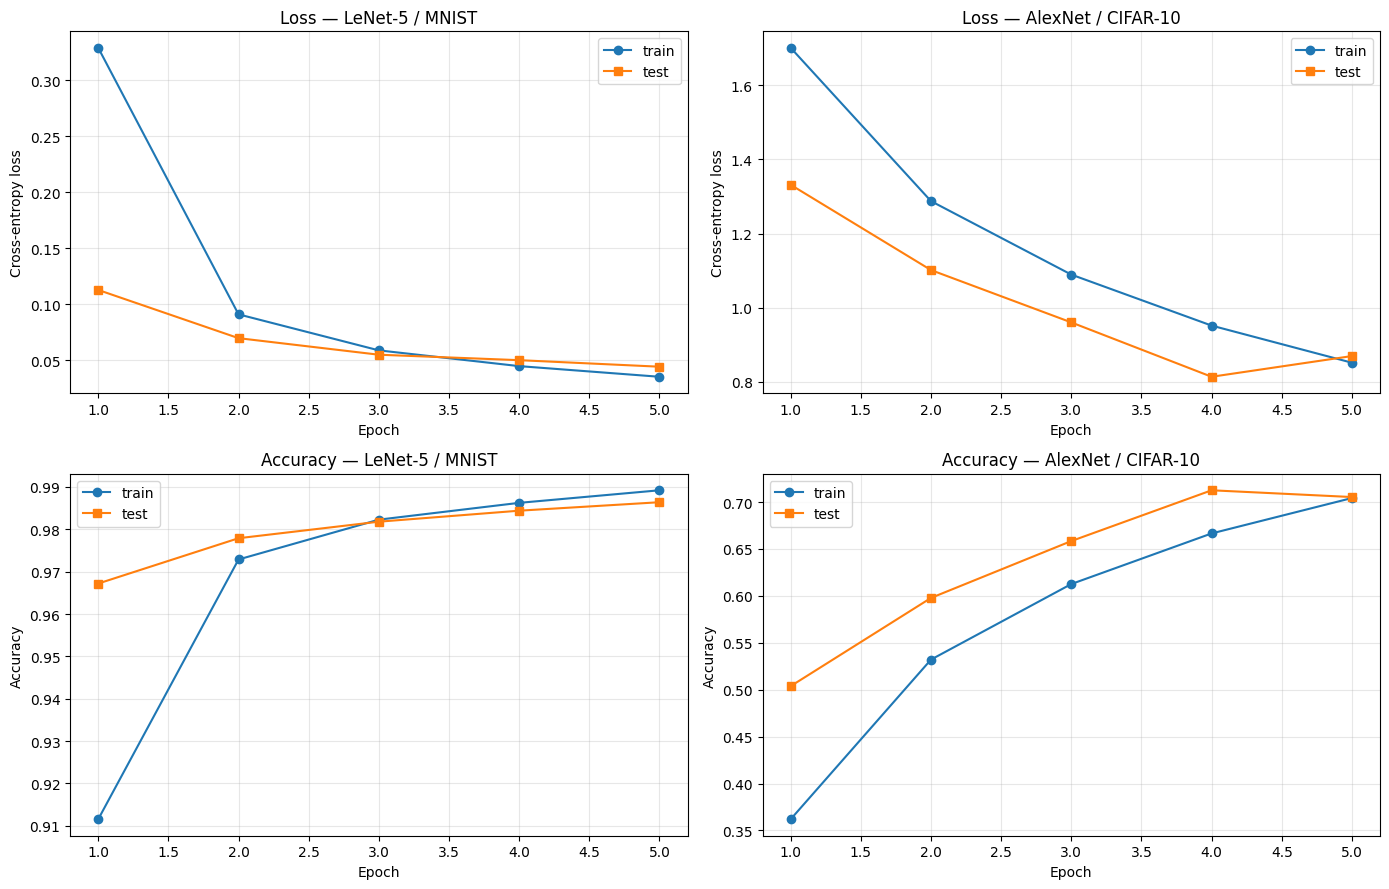

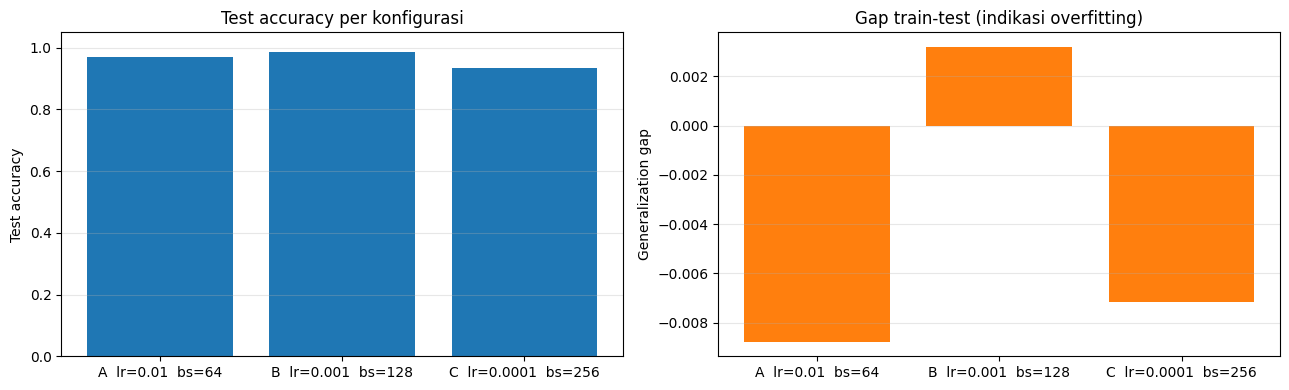

In [27]:
# ============================================================
# VISUALISASI
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for col, (name, history) in enumerate([('LeNet-5 / MNIST', lenet_history),
                                       ('AlexNet / CIFAR-10', alexnet_history)]):
    epochs = [h['epoch'] for h in history]
    axes[0, col].plot(epochs, [h['train_loss'] for h in history], marker='o', label='train')
    axes[0, col].plot(epochs, [h['test_loss'] for h in history], marker='s', label='test')
    axes[0, col].set_title(f'Loss — {name}')
    axes[0, col].set_xlabel('Epoch')
    axes[0, col].set_ylabel('Cross-entropy loss')
    axes[0, col].legend()
    axes[0, col].grid(alpha=0.3)

    axes[1, col].plot(epochs, [h['train_acc'] for h in history], marker='o', label='train')
    axes[1, col].plot(epochs, [h['test_acc'] for h in history], marker='s', label='test')
    axes[1, col].set_title(f'Accuracy — {name}')
    axes[1, col].set_xlabel('Epoch')
    axes[1, col].set_ylabel('Accuracy')
    axes[1, col].legend()
    axes[1, col].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Perbandingan hyperparameter pada LeNet-5 / MNIST
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
labels = [f"{r['eksperimen']}  lr={r['learning_rate']:g}  bs={int(r['batch_size'])}"
          for _, r in results_df.iterrows()]
x = range(len(results_df))
ax[0].bar(x, results_df['test_acc'], color='tab:blue')
ax[0].set_xticks(list(x))
ax[0].set_xticklabels(labels)
ax[0].set_ylim(0, 1.05)
ax[0].set_ylabel('Test accuracy')
ax[0].set_title('Test accuracy per konfigurasi')

ax[1].bar(x, results_df['gap'], color='tab:orange')
ax[1].set_xticks(list(x))
ax[1].set_xticklabels(labels)
ax[1].set_ylabel('Generalization gap')
ax[1].set_title('Gap train-test (indikasi overfitting)')

for a in ax:
    a.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### 4.3 Analisis dan Interpretasi

**Perbandingan arsitektur.** LeNet-5 bekerja sangat baik pada MNIST. Dataset ini hanya berisi digit grayscale dengan kontras tinggi dan posisi yang selalu di tengah, sehingga setelah resolusinya diturunkan pun informasi pembeda masih tersisa. AlexNet bekerja pada CIFAR-10 yang jauh lebih beragam: sepuluh kelas objek dengan latar belakang, pencahayaan, dan orientasi yang bervariasi, serta objeknya kadang hanya berukuran beberapa piksel. Karena itu akurasi AlexNet setelah lima epoch masih jauh dari performa AlexNet penuh pada ImageNet, dan hal ini normal, bukan tanda implementasi yang keliru.

**Pengaruh learning rate.** Learning rate menentukan seberapa jauh model boleh bergerak pada setiap langkah. Pada 1e-2, langkah tersebut terlalu lebar sehingga optimizer dapat melewati lembah loss minimum berulang kali, dan kurva training tampak tidak stabil. Pada 1e-4, gerakannya aman dan stabil, tetapi progresnya sangat lambat sehingga lima epoch belum cukup untuk menangkap konvergensi. Nilai 1e-3 berada di antara keduanya: progres cepat tanpa instabilitas berarti. Inilah sebabnya angka pada tabel harus dibaca bersama grafik, bukan berdiri sendiri. Konfigurasi dengan akurasi akhir tertinggi belum tentu yang paling hemat waktu.

**Pengaruh batch size.** Batch yang lebih besar menghasilkan gradien yang lebih rapat dan mengurangi noise estimasi, sehingga training terasa lebih halus per epoch. Namun jumlah langkah update per epoch berkurang, dan waktu tiap epoch bisa naik karena ada lebih banyak data per batch. Batch kecil menambah noise, yang kadang berguna untuk keluar dari *sharp minima*, tetapi memperbesar kemungkinan gradien terlalu kasar. Perhatikan kolom `detik_per_epoch`: waktu per epoch tidak hanya bergantung pada batch size, tetapi juga pada arsitektur, sehingga tidak dapat dibandingkan langsung antar tabel tanpa memperhitungkan modelnya.

**Generalisasi dan overfitting.** LeNet-5 dengan 61.706 parameter untuk 60.000 contoh memiliki kapasitas yang sangat dekat dengan ukuran data, sehingga gap training dan test-nya diharapkan kecil. AlexNet memiliki kapasitas yang jauh melebihi ukuran dataset CIFAR-10, dan di sinilah dropout 0,5, augmentasi, serta weight decay dari Adam benar-benar bekerja. Tanpa mekanisme tersebut, gap-nya akan jauh lebih lebar. Karena training dibatasi lima epoch, sebagian besar konfigurasi belum sempat overfit secara signifikan. Oleh karena itu, kesimpulan bahwa tidak ada overfitting pada eksperimen ini tidak boleh digeneralisasi ke training yang lebih panjang.

**Keterbatasan.** Tiga keterbatasan perlu diakui. Pertama, lima epoch terlalu sedikit untuk CIFAR-10 dan untuk learning rate 1e-4 pada khususnya. Kedua, sweep hanya dijalankan pada satu arsitektur dan satu dataset, sehingga pengaruh interaksi antara arsitektur dan hyperparameter belum terlihat. Ketiga, laporan ini belum menyajikan confusion matrix maupun analisis per kelas, sehingga kelas mana yang paling sulit diklasifikasi belum teridentifikasi.

**Saran perbaikan.** Untuk eksperimen lanjutan, langkah yang paling masuk akal adalah menaikkan jumlah epoch, menambahkan learning-rate scheduler seperti cosine annealing agar langkah mengecil seiring waktu, memperbanyak variasi augmentasi dengan `RandomAffine` atau color jitter, serta menyajikan confusion matrix untuk melihat kelas yang tertukar. Menambah batch normalization dan membandingkan AdamW dengan weight decay terpisah juga layak dicoba, karena keduanya redesigned tersebut menjadi arah yang akan diambil arsitektur pada Pertemuan 06.

## BAB 5 — KESIMPULAN DAN SARAN

### 5.1 Kesimpulan

Kesimpulan berikut dihasilkan secara otomatis oleh sel di bawahnya, dibaca langsung dari hasil training yang sebenarnya, bukan dari asumsi. Yang dicantumkan meliputi performa masing-masing model, konfigurasi hyperparameter terbaik, pengaruh learning rate dan batch size, serta indikasi overfitting dari besarnya gap training terhadap test.


In [28]:
# Kesimpulan otomatis dari epoch terakhir setiap eksperimen
print('ANALISIS OTOMATIS')
for name, history in [('LeNet-5 / MNIST', lenet_history),
                      ('AlexNet-CIFAR / CIFAR-10', alexnet_history)]:
    last = history[-1]
    print(f'- {name}: train_acc={last["train_acc"]:.3f}, test_acc={last["test_acc"]:.3f}, '
          f'test_loss={last["test_loss"]:.3f}, gap={last["train_acc"] - last["test_acc"]:.3f}')

print(f"- Eksperimen terbaik: {best['eksperimen']} "
      f"(lr={best['learning_rate']:g}, bs={int(best['batch_size'])}, "
      f"test_acc={best['test_acc']:.3f})")

for _, r in results_df.iterrows():
    print(f"- Eksperimen {r['eksperimen']}: lr={r['learning_rate']:g}, "
          f"bs={int(r['batch_size'])}, test_acc={r['test_acc']:.3f}, "
          f"gap={r['gap']:.3f}, {r['detik_per_epoch']:.1f}s/epoch")

gap_max = results_df['gap'].max()
gap_lenet = lenet_history[-1]['train_acc'] - lenet_history[-1]['test_acc']
gap_alexnet = alexnet_history[-1]['train_acc'] - alexnet_history[-1]['test_acc']
print(f'- Gap train-test maksimum pada sweep: {gap_max:.3f}')
print(f'- Gap LeNet-5/MNIST: {gap_lenet:.3f}; AlexNet/CIFAR-10: {gap_alexnet:.3f}')
print('KESIMPULAN:', 'Ada indikasi overfitting.' if max(gap_max, gap_lenet, gap_alexnet) > 0.10
      else 'Gap train-test masih terkendali pada eksperimen ini.')
print('KESIMPULAN: LeNet-5 adequate untuk MNIST dengan parameter jauh lebih sedikit, '
      'sedangkan AlexNet perlu adaptasi resolusi dan mendapat manfaat dari '
      'augmentasi untuk CIFAR-10.')
print('SARAN: tambah epoch, learning-rate scheduler, augmentasi tambahan, dan confusion matrix.')

ANALISIS OTOMATIS
- LeNet-5 / MNIST: train_acc=0.989, test_acc=0.986, test_loss=0.044, gap=0.003
- AlexNet-CIFAR / CIFAR-10: train_acc=0.704, test_acc=0.705, test_loss=0.869, gap=-0.001
- Eksperimen terbaik: B (lr=0.001, bs=128, test_acc=0.987)
- Eksperimen A: lr=0.01, bs=64, test_acc=0.970, gap=-0.009, 25.4s/epoch
- Eksperimen B: lr=0.001, bs=128, test_acc=0.987, gap=0.003, 22.7s/epoch
- Eksperimen C: lr=0.0001, bs=256, test_acc=0.936, gap=-0.007, 21.1s/epoch
- Gap train-test maksimum pada sweep: 0.003
- Gap LeNet-5/MNIST: 0.003; AlexNet/CIFAR-10: -0.001
KESIMPULAN: Gap train-test masih terkendali pada eksperimen ini.
KESIMPULAN: LeNet-5 adequate untuk MNIST dengan parameter jauh lebih sedikit, sedangkan AlexNet perlu adaptasi resolusi dan mendapat manfaat dari augmentasi untuk CIFAR-10.
SARAN: tambah epoch, learning-rate scheduler, augmentasi tambahan, dan confusion matrix.


### 5.2 Keterbatasan

Eksperimen ini memiliki beberapa keterbatasan: jumlah epoch relatif singkat, belum menggunakan validation split, dan perbandingan arsitektur melibatkan dataset yang berbeda sehingga hasilnya tidak dapat dianggap sebagai perbandingan murni antar-model. Selain itu, ketersediaan GPU, versi library, dan faktor randomisasi dapat memengaruhi waktu serta hasil pelatihan.


In [29]:
# Validasi keterbatasan eksperimen P05
print('VALIDASI KETERBATASAN')
print(f'Jumlah epoch LeNet-5 : {len(lenet_history)}')
print(f'Jumlah epoch AlexNet : {len(alexnet_history)}')
print(f'Jumlah konfigurasi hyperparameter: {len(results_df)}')
print(f'Kolom hasil tersedia : {list(results_df.columns)}')
assert len(lenet_history) > 0 and len(alexnet_history) > 0
assert {'test_acc','test_loss','gap'}.issubset(results_df.columns)
print('Validation split terpisah: tidak digunakan pada eksperimen ini.')
print('Perbandingan LeNet-5 dan AlexNet menggunakan dataset berbeda: MNIST dan CIFAR-10.')
print('Status: informasi keterbatasan terverifikasi dari objek hasil eksperimen.')


VALIDASI KETERBATASAN
Jumlah epoch LeNet-5 : 5
Jumlah epoch AlexNet : 5
Jumlah konfigurasi hyperparameter: 3
Kolom hasil tersedia : ['eksperimen', 'learning_rate', 'batch_size', 'train_loss', 'train_acc', 'test_loss', 'test_acc', 'gap', 'detik_per_epoch']
Validation split terpisah: tidak digunakan pada eksperimen ini.
Perbandingan LeNet-5 dan AlexNet menggunakan dataset berbeda: MNIST dan CIFAR-10.
Status: informasi keterbatasan terverifikasi dari objek hasil eksperimen.


### 5.3 Saran Pengembangan

Eksperimen lanjutan dapat menambah jumlah epoch, menggunakan validation split dan learning-rate scheduler, memperluas variasi augmentasi, serta menyajikan confusion matrix. Pengujian arsitektur modern dengan prosedur evaluasi yang sama juga dapat memberikan perbandingan yang lebih komprehensif.


In [30]:
# Saran otomatis berdasarkan hasil eksperimen P05
print('SARAN OTOMATIS')
max_gap=float(max(results_df['gap'].max(), lenet_history[-1]['train_acc']-lenet_history[-1]['test_acc'], alexnet_history[-1]['train_acc']-alexnet_history[-1]['test_acc']))
if len(lenet_history) <= 5 or len(alexnet_history) <= 5:
    print('- Tambahkan epoch untuk memastikan model telah mencapai konvergensi.')
if max_gap > 0.10:
    print('- Gunakan validation split, early stopping, atau regularisasi untuk mengurangi overfitting.')
else:
    print('- Gap train-test masih terkendali; ulangi dengan beberapa seed untuk menguji kestabilan.')
print('- Tambahkan scheduler learning rate dan confusion matrix pada eksperimen berikutnya.')
print(f'- Gap train-test maksimum yang teramati: {max_gap:.3f}')


SARAN OTOMATIS
- Tambahkan epoch untuk memastikan model telah mencapai konvergensi.
- Gap train-test masih terkendali; ulangi dengan beberapa seed untuk menguji kestabilan.
- Tambahkan scheduler learning rate dan confusion matrix pada eksperimen berikutnya.
- Gap train-test maksimum yang teramati: 0.003


## REFERENSI

### Arsitektur CNN Klasik

1. LeCun, Y., Bottou, L., Bengio, Y., dan Haffner, P. (1998). *Gradient-Based Learning Applied to Document Recognition*. Proceedings of the IEEE, 86(11), 2278-2324.
2. Krizhevsky, A., Sutskever, I., dan Hinton, G. E. (2012). *ImageNet Classification with Deep Convolutional Neural Networks*. Advances in Neural Information Processing Systems, 25, 1097-1105.

### Teori dan Fundamentals

3. Goodfellow, I., Bengio, Y., dan Courville, A. (2016). *Deep Learning*. MIT Press. Bab 5, 7, dan 9.
4. Glorot, X., dan Bengio, Y. (2010). *Understanding the Difficulty of Training Deep Feedforward Neural Networks*. Proceedings of the 13th International Conference on Artificial Intelligence and Statistics, 249-256.
5. LeCun, Y., Bottou, L., Bengio, Y., dan Haffner, P. (1998). *Efficient BackProp*. Neural Networks: Tricks of the Trade, Springer, 9-50.
6. Rumelhart, D. E., Hinton, G. E., dan Williams, R. J. (1986). *Learning Representations by Back-Propagating Errors*. Nature, 323(6088), 533-536.
7. Ioffe, S., dan Szegedy, C. (2015). *Batch Normalization: Accelerating Deep Network Training by Reducing Internal Covariate Shift*. Proceedings of the 32nd International Conference on Machine Learning, 448-456.

### Regularisasi dan Augmentasi

8. Srivastava, N., Hinton, G., Krizhevsky, A., Sutskever, I., dan Salakhutdinov, R. (2014). *Dropout: A Simple Way to Prevent Neural Networks from Overfitting*. Journal of Machine Learning Research, 15, 1929-1958.
9. Shorten, C., dan Khoshgoftaar, T. M. (2019). *A Survey on Image Data Augmentation for Deep Learning*. Journal of Big Data, 6(1), 60.
10. Luo, W., et al. (2020). *A Survey on Random Augmentation for Deep Learning*. Journal of Big Data, 7, 32.

### Optimasi dan Hyperparameter

11. Kingma, D. P., dan Ba, J. (2015). *Adam: A Method for Stochastic Optimization*. International Conference on Learning Representations.
12. Loshchilov, I., dan Hutter, F. (2019). *Decoupled Weight Decay Regularization*. International Conference on Learning Representations.
13. Smith, L. A., et al. (2015). *On Large-Scale Training of Deep Neural Networks*. International Conference on Learning Representations.
14. Loshchilov, I., dan Hutter, F. (2017). *SGDR: Stochastic Gradient Descent with Warm Restarts*. International Conference on Learning Representations.
15. Bergstra, J., dan Bengio, Y. (2012). *Random Search for Hyper-Parameter Optimization*. Journal of Machine Learning Research, 13, 281-305.
16. Loshchilov, I., dan Hutter, F. (2019). *On the Connection between Adam and Stochastic Gradient Descent*. International Conference on Learning Representations.

### Arsitektur Modern

17. He, K., Zhang, X., Ren, S., dan Sun, J. (2015). *Delving Deep into Rectifiers: Surpassing Human-Level Performance on ImageNet Classification*. IEEE International Conference on Computer Vision, 1026-1034.
18. Simonyan, K., dan Zisserman, A. (2015). *Very Deep Convolutional Networks for Large-Scale Image Recognition*. International Conference on Learning Representations.
19. He, K., Zhang, X., Ren, S., dan Sun, J. (2016). *Deep Residual Learning for Image Recognition*. IEEE Conference on Computer Vision and Pattern Recognition, 770-778.
20. Huang, G., et al. (2017). *Squeeze-and-Excitation Networks*. IEEE Conference on Computer Vision and Pattern Recognition, 7132-7141.
21. Howard, A. G., et al. (2017). *MobileNets: Efficient Convolutional Neural Networks for Mobile Vision Applications*. arXiv:1704.04861.
22. Chen, B., et al. (2018). *MobileNetV2: Inverted Residuals and Linear Bottlenecks*. IEEE Conference on Computer Vision and Pattern Recognition, 4510-4520.
23. Tan, M., dan Le, Q. V. (2019). *EfficientNet: Rethinking Model Scaling for Convolutional Neural Networks*. Proceedings of the 36th International Conference on Machine Learning, 6105-6114.
24. Liu, Z., et al. (2022). *A ConvNet for the 2020s*. IEEE Conference on Computer Vision and Pattern Recognition, 11966-11976.
25. Oquab, M., et al. (2023). *DINOv2: Learning Robust Visual Features without Supervision*. Transactions on Machine Learning Research.

### Dataset

26. Krizhevsky, A. (2009). *Learning Multiple Layers of Features from Tiny Images*. University of Toronto, Technical Report TR-2007.
27. Deng, J., et al. (2009). *ImageNet: A Large-Scale Hierarchical Image Database*. IEEE Conference on Computer Vision and Pattern Recognition, 248-255.

### Perkakas dan Dokumentasi Resmi

28. Paszke, A., et al. (2019). *PyTorch: An Imperative Style, High-Performance Deep Learning Library*. Advances in Neural Information Processing Systems, 32, 8024-8035.
29. McKinney, W. (2010). *Data Analysis Using Python and Pandas*. O'Reilly Media.
30. Hunter, J. D. (2007). *Matplotlib: A 2D Graphics Environment*. Computing in Science and Engineering, 9(3), 90-95.
31. Dokumentasi resmi PyTorch. `torch.nn`, `torch.optim`, `torch.utils.data`, `torch.save`.
32. Dokumentasi resmi Torchvision. `torchvision.datasets`, `torchvision.transforms`.